<a href="https://colab.research.google.com/github/scardenol/Numerical_Analysis_2026/blob/main/Taller%201/3_opt_no_lineal_con_restricciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 1 - Punto 3

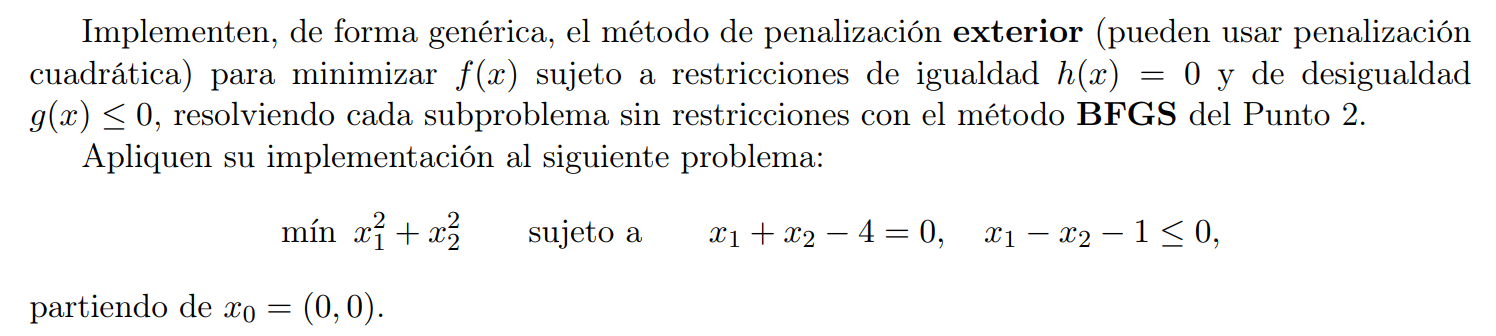

In [1]:
# Cargar librerías
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

In [2]:
# Funciones auxiliares

# Función para aproximar el gradiente de f usando diferencias finitas centradas
def gradiente_numerico(f, x, h=1e-5):
  """
  Aproximación del gradiente de una función usando diferencias finitas centradas.
  """
  x = np.asarray(x, dtype=float) # array tipo float
  C = np.eye(len(x)) * h # Matriz I*h
  return np.array([(f(x + c) - f(x - c)) / (2 * h) for c in C])

# Función para hacer la búsqueda lineal inexacta por criterio de Armijo
def busqueda_lineal_armijo(f, grad_f, x, d, phi0, alpha=1, rho=0.5, c1=1e-4):
  """
  Función para realizar la búsqueda de línea inexacta usando la conndición de Armijo.
  Se pasa phi0 para evitar el costo de volver a evaluar.
  """
  phi_alpha = f(x + alpha * d)
  grad_phi_alpha = np.dot(grad_f, d)
  while phi_alpha > phi0 + c1 * alpha * grad_phi_alpha:
    alpha = rho * alpha
    phi_alpha = f(x + alpha * d)
  return alpha

def bfgs(f, x0, tol=1e-6, max_iter=1000, verbose=True, print_every=10):
  """
  Método BFGS (Quasi-Newton) para minimizar una función. Aproxima iterativamente
  la inversa de la Hessiana (H_k) usando únicamente evaluaciones del gradiente,
  sin calcular la Hessiana real. Usa la búsqueda lineal inexacta con criterio
  de Armijo para encontrar el tamaño de paso alpha.
  """

  # Parámetros iniciales
  x = np.asarray(x0, dtype=float)
  n = len(x)
  H = np.eye(n) # H_0 = I pues no hay información de curvatura todavía, primer paso = gradiente descendente
  grad_f = gradiente_numerico(f, x)

  historial_x = [x.copy()]
  historial_norma = [np.linalg.norm(grad_f)]

  # Ciclo principal
  for i in range(max_iter):
    fx = f(x)
    norma_gradiente = np.linalg.norm(grad_f)

    if verbose and i % print_every == 0:
      print(f"Iter {i:4d} | f(x) = {fx:>10.4g} | ||grad|| = {norma_gradiente:>10.4g} | x = {x}")

    # Criterio de parada
    if norma_gradiente < tol:
      if verbose:
        print(f"\nConvergencia alcanzada en la iteración {i} | f(x) = {fx:.4g}")
      break

    d = -H @ grad_f # Dirección Quasi-Newton

    alpha = busqueda_lineal_armijo(f, grad_f, x, d, fx) # Tamaño de paso
    x_nuevo = x + alpha * d # Próximo valor
    grad_f_nuevo = gradiente_numerico(f, x_nuevo)

    # Actualización BFGS de H
    s = (x_nuevo - x).reshape(-1, 1)
    y = (grad_f_nuevo - grad_f).reshape(-1, 1)
    rho = 1.0 / (y.T @ s).item()

    I = np.eye(n)
    H = (I - rho * s @ y.T) @ H @ (I - rho * y @ s.T) + rho * s @ s.T

    # Avanzar a la siguiente iteración
    x = x_nuevo
    grad_f = grad_f_nuevo

    # Guardar valores en el historial
    historial_x.append(x.copy())
    historial_norma.append(norma_gradiente)

  return x, np.array(historial_x), np.array(historial_norma)

# Método de Penalización Exterior

\begin{gather*}
P(x; \mu) = f(x) + \mu \psi\big(h(x), g(x)\big)
\end{gather*}

donde
- $\mu > 0$ es el parámetro de penalización.
- $\psi$ es la función de penalización. Se debe cumplir que la penalización sea positiva para puntos por fuera de la región factible y que sea 0 para puntos dentro de la región factible, i.e. simbólicamente, $\psi > 0 \;\forall x \notin S \;\; \wedge \;\; \psi=0 \; \forall x \in S$.
- Por lo anterior, el término $\mu \psi\big(h(x), g(x)\big)$ representa el "castigo" sobre $f(x)$, que no es más que un nivel de traslación para intentar mantener la dirección de la función hacia el óptimo.

La forma más común de $P$ proviene de considerar la función de penalización $\psi$ definida implícitamente como
\begin{gather*}
P(x; \mu) = f(x) + \mu \left[ \sum_{k=1}^l |h_k(x)|^\alpha + \sum_{j=1}^m |g_j(x)|_+^\beta \right], \quad \alpha, \beta \geq 1
\end{gather*}
donde
- Claramente, $\psi = \sum_{k=1}^l |h_k(x)|^\alpha + \sum_{j=1}^m |g_j(x)|^\beta$.
- $|g_j(x)|_+ = \max\{g_j, \;0\}$ es un operador de no-negatividad.
- Si $\alpha = \beta = 1$ se llama **penalización valor absoluto**, mientras que si $\alpha=\beta=2$ se llama **penalización cuadrática**.


In [3]:
def penalizacion_exterior(f, x0, h=None, g=None, mu1=1.0, eta=2.0, alpha=2, beta=2,
                            tol=1e-4, max_iter=50, tol_int=1e-6, max_iter_int=1000,
                            verbose=True):
  """
  Método de penalización exterior para resolver problemas con restricciones
  de igualdad h(x) = 0 y desigualdad g(x) <= 0. Resuelve una secuencia de
  subproblemas sin restricciones P(x; mu_n) = f(x) + mu_n * psi(x), usando
  BFGS en cada subproblema, con x_{n-1} como punto inicial (warm start).
  Se asume alpha=beta=2 para la penalización cuadrática.

  Parámetros:
    f: función objetivo f(x)
    x0: punto inicial
    h: lista de funciones de igualdad h_k(x), o None si no hay
    g: lista de funciones de desigualdad g_j(x), o None si no hay
    mu1: parámetro de penalización inicial
    eta: factor de incremento de mu en cada iteración externa (eta > 1)
    alpha, beta: exponentes de penalización (2 = cuadrática, 1 = valor absoluto)
    tol, max_iter: tolerancia y máximo de iteraciones del algoritmo
    tol_int, max_iter_int: tolerancia y máximo de iteraciones de cada BFGS interno
  """
  h = h or []
  g = g or []

  def psi(x):
    total = 0.0
    for hk in h:
      total += np.abs(hk(x))**alpha
    for gj in g:
      total += max(gj(x), 0.0)**beta  # |g_j(x)|_+ = max(g_j(x), 0)
    return total

  def P(x, mu):
    return f(x) + mu * psi(x)

  # Parámetros iniciales
  x = np.asarray(x0, dtype=float)
  mu = mu1
  historial_x = [x.copy()]
  historial_mu = [mu]

  # Ciclo principal (externo)
  for n in range(1, max_iter + 1):
    x_anterior = x.copy()

    # Paso 2: resolver el subproblema sin restricciones con BFGS, partiendo de x_{n-1}
    f_penalizada = lambda x: P(x, mu)
    x, _, _ = bfgs(f_penalizada, x_anterior, tol=tol_int, max_iter=max_iter_int, verbose=False)

    diff = np.linalg.norm(x - x_anterior)

    if verbose:
      print(f"Iter {n:3d} | mu = {mu:>10.4g} | f(x) = {f(x):>10.4g} | "
            f"psi(x) = {psi(x):>10.4g} | ||x_n - x_(n-1)|| = {diff:>10.4g} | x = {x}")

    historial_x.append(x.copy())
    historial_mu.append(mu)

    # Paso 3: criterio de parada
    if diff < tol:
      if verbose:
        print(f"\nConvergencia alcanzada en la iteración {n} | x = {x}")
      break

    # Paso 4: incrementar mu y continuar
    mu = eta * mu

  return x, np.array(historial_x), np.array(historial_mu)

# Problema

\begin{gather*}
\min_x x_1^2+x_2^2 \\[12pt]
s.a. \begin{cases} x_1+x_2-4=0,\\ x_1-x_2-1 \leq 0 \end{cases}
\end{gather*}

In [4]:
# Definir la función como una lambda fun
f = lambda x: x[0]**2 + x[1]**2

# Definir las restricciones de igualdad y desigualdad como lambda fun
h1 = lambda x: x[0] + x[1] - 4        # h(x) = 0
g1 = lambda x: x[0] - x[1] - 1        # g(x) <= 0

# Punto inicial
x0 = [0, 0]

# Correr el método e imprimir resultados
x_final, historial_x, historial_mu = penalizacion_exterior(f, x0, h=[h1], g=[g1])

print(f"\nSolución aproximada: {x_final}")
print(f"h(x_final) = {h1(x_final)}")
print(f"g(x_final) = {g1(x_final)}")

Iter   1 | mu =          1 | f(x) =      3.556 | psi(x) =      1.778 | ||x_n - x_(n-1)|| =      1.886 | x = [1.33333333 1.33333333]
Iter   2 | mu =          2 | f(x) =       5.12 | psi(x) =       0.64 | ||x_n - x_(n-1)|| =     0.3771 | x = [1.6 1.6]
Iter   3 | mu =          4 | f(x) =      6.321 | psi(x) =     0.1975 | ||x_n - x_(n-1)|| =     0.2514 | x = [1.77777778 1.77777778]
Iter   4 | mu =          8 | f(x) =      7.087 | psi(x) =    0.05536 | ||x_n - x_(n-1)|| =     0.1479 | x = [1.88235294 1.88235294]
Iter   5 | mu =         16 | f(x) =      7.522 | psi(x) =    0.01469 | ||x_n - x_(n-1)|| =    0.08067 | x = [1.93939394 1.93939394]
Iter   6 | mu =         32 | f(x) =      7.756 | psi(x) =   0.003787 | ||x_n - x_(n-1)|| =     0.0422 | x = [1.96923077 1.96923077]
Iter   7 | mu =         64 | f(x) =      7.876 | psi(x) =  0.0009615 | ||x_n - x_(n-1)|| =    0.02159 | x = [1.98449612 1.98449612]
Iter   8 | mu =        128 | f(x) =      7.938 | psi(x) =  0.0002422 | ||x_n - x_(n-1)|| =

# Visualización de trayectorias de convergencia

In [5]:
def graficar_curvas_nivel(f, x1_range=(-2, 2), x2_range=(-1, 3), n=200,
                            trayectorias=None, restricciones=None, niveles=30,
                            log_scale=False, titulo=None):
  """
  Grafica las curvas de nivel de una función f(x1, x2) y opcionalmente las trayectorias
  de convergencia de algoritmos de optimización, junto con curvas de restricciones
  h(x) = 0 (igualdad) o g(x) <= 0 (desigualdad, con región factible sombreada).
  """

  # Crear malla
  x1 = np.linspace(*x1_range, n)
  x2 = np.linspace(*x2_range, n)
  X1, X2 = np.meshgrid(x1, x2)
  Z = f(X1, X2)

  # Parámetros de la figura y ejes
  fig, ax = plt.subplots(figsize=(8, 6))

  if log_scale:
    z_min = max(Z.min(), 1e-10)
    levels = np.logspace(np.log10(z_min), np.log10(Z.max()), niveles)
  else:
    levels = niveles

  cf = ax.contourf(X1, X2, Z, levels=levels, cmap='viridis', alpha=0.3)
  ax.contour(X1, X2, Z, levels=levels, cmap='viridis')
  fig.colorbar(cf, ax=ax, label='f(x1, x2)')

  # Dibujar restricciones si se pasan
  if restricciones:
    for nombre, (r, tipo) in restricciones.items():
      R = r(X1, X2)  # r debe ser vectorizable, ej. lambda x1, x2: x1 + x2 - 4

      if tipo == 'g':
        # Sombrear la región factible: donde R <= 0
        ax.contourf(X1, X2, R, levels=[-np.inf, 0], colors=['#ff7f0e'], alpha=0.15)
        cr = ax.contour(X1, X2, R, levels=[0], colors='#ff7f0e', linewidths=2, linestyles='--')
      else:  # tipo == 'h'
        cr = ax.contour(X1, X2, R, levels=[0], colors='darkred', linewidths=2.5, linestyles='-')

      ax.clabel(cr, fmt={0: nombre}, inline=True, fontsize=9)

  # Superponer trayectorias si se pasan
  if trayectorias:
    colores = plt.cm.tab10.colors
    for idx, (nombre, historial) in enumerate(trayectorias.items()):
      historial = np.asarray(historial)
      color = colores[idx % len(colores)]
      ax.plot(historial[:, 0], historial[:, 1], 'o-', color=color,
              markersize=3, linewidth=1.2, label=nombre)
      ax.plot(*historial[0], 'o', color=color, markersize=8, markeredgecolor='black')   # inicio
      ax.plot(*historial[-1], '*', color=color, markersize=14, markeredgecolor='black') # final
    ax.legend()

  ax.set_xlabel('x1')
  ax.set_ylabel('x2')
  ax.set_title(titulo or 'Curvas de nivel')
  plt.tight_layout()
  plt.show()

In [6]:
def graficar_superficie_3d(f, x1_range=(-2, 2), x2_range=(-1, 3), n=100,
                             trayectorias=None, restricciones=None, titulo=None):
  """
  Grafica la superficie 3D de f(x1, x2) con Plotly y opcionalmente superpone
  las trayectorias de convergencia y las curvas de restricciones h(x)=0, g(x)<=0
  (drapeadas sobre la superficie), con la región factible de g sombreada en el piso.
  """

  # Crear malla
  x1 = np.linspace(*x1_range, n)
  x2 = np.linspace(*x2_range, n)
  X1, X2 = np.meshgrid(x1, x2)
  Z = f(X1, X2)
  z_piso = Z.min() - 0.05 * (Z.max() - Z.min())  # nivel del "piso" para proyecciones

  data = [go.Surface(
      z=Z, x=X1, y=X2,
      contours={
          "x": {"show": True, "start": x1_range[0], "end": x1_range[1], "size": 0.2, "color": "white"},
          "y": {"show": True, "start": x2_range[0], "end": x2_range[1], "size": 0.2, "color": "white"},
      },
      opacity=0.85,
      colorscale='Viridis',
      showscale=True
  )]

  # Dibujar restricciones si se pasan
  if restricciones:
    for nombre, (r, tipo) in restricciones.items():
      R = r(X1, X2)

      # Extraer la curva de nivel 0 usando matplotlib, sin mostrarla
      fig_tmp, ax_tmp = plt.subplots()
      cs = ax_tmp.contour(X1, X2, R, levels=[0])
      segmentos = cs.allsegs[0]  # lista de arrays (n_puntos, 2) por cada segmento de la curva
      plt.close(fig_tmp)

      color = 'darkred' if tipo == 'h' else '#ff7f0e'
      dash = 'solid' if tipo == 'h' else 'dash'

      for k, seg in enumerate(segmentos):
        z_seg = f(seg[:, 0], seg[:, 1]) + 5  # drapeada sobre la superficie, mismo offset que trayectorias
        data.append(go.Scatter3d(
            x=seg[:, 0], y=seg[:, 1], z=z_seg,
            mode='lines',
            line=dict(color=color, width=6, dash=dash),
            name=nombre, showlegend=(k == 0)  # una sola entrada en leyenda aunque haya varios segmentos
        ))

      # Región factible sombreada en el piso, solo para desigualdades
      if tipo == 'g':
        mascara = np.where(R <= 0, z_piso, np.nan)  # NaN = transparente/no dibujado
        data.append(go.Surface(
            z=mascara, x=X1, y=X2,
            showscale=False, opacity=0.25,
            colorscale=[[0, '#ff7f0e'], [1, '#ff7f0e']],
            name=f'Región factible ({nombre})'
        ))

  # Superponer trayectorias si se pasan
  if trayectorias:
    colores_plotly = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for idx, (nombre, historial) in enumerate(trayectorias.items()):
      historial = np.asarray(historial)
      color = colores_plotly[idx % len(colores_plotly)]
      z_historial = f(historial[:, 0], historial[:, 1]) + 5

      data.append(go.Scatter3d(
          x=historial[:, 0], y=historial[:, 1], z=z_historial,
          mode='lines+markers',
          line=dict(color=color, width=4),
          marker=dict(size=3, color=color),
          name=nombre
      ))
      data.append(go.Scatter3d(
          x=[historial[0, 0]], y=[historial[0, 1]], z=[z_historial[0]],
          mode='markers', marker=dict(size=6, color=color, symbol='circle',
                                        line=dict(color='black', width=1)),
          showlegend=False
      ))
      data.append(go.Scatter3d(
          x=[historial[-1, 0]], y=[historial[-1, 1]], z=[z_historial[-1]],
          mode='markers', marker=dict(size=8, color=color, symbol='diamond',
                                        line=dict(color='black', width=1)),
          showlegend=False
      ))

  fig = go.Figure(data=data)

  fig.update_layout(
      width=800,
      height=700,
      title=titulo,
      scene=dict(
          xaxis_title='x₁',
          yaxis_title='x₂',
          zaxis_title='f(x₁, x₂)',
          aspectmode='cube'
      ),
      legend=dict(
          x=0.02, y=0.98,
          xanchor='left', yanchor='top',
          bgcolor='rgba(255,255,255,0.7)',
          bordercolor='black',
          borderwidth=1
      ),
      margin=dict(l=30, r=30, t=50, b=60)
  )

  return fig

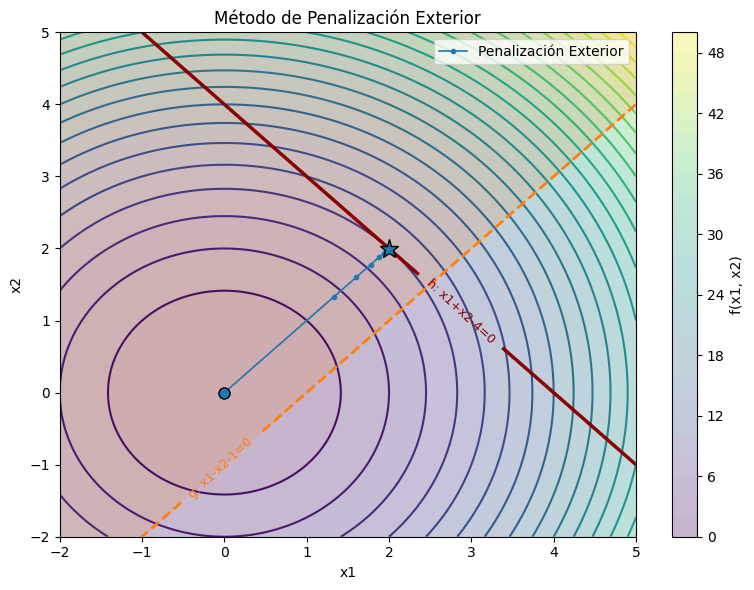

In [7]:
f = lambda x1, x2: x1**2 + x2**2

restricciones = {
    'h: x1+x2-4=0': (lambda x1, x2: x1 + x2 - 4, 'h'),
    'g: x1-x2-1=0': (lambda x1, x2: x1 - x2 - 1, 'g'),
}

graficar_curvas_nivel(f, x1_range=(-2, 5), x2_range=(-2, 5),
                       trayectorias={'Penalización Exterior': historial_x},
                       restricciones=restricciones,
                       titulo='Método de Penalización Exterior')

La gráfica anterior muestra la trayectoria del método desde el punto inicial al óptimo. Note que el punto inicial se encuentra dentro de la región de la restricción de desigualdad (naranja transparente) con frontera (naranja) punteada. Por otro lado, la restricción de igualdad es la recta (rojo oscuro) donde se encuentra el óptimo.

Claramente, la región factible corresponde a la sección de dicha restricción dentro de la región naranja (intersección de los conjuntos de ambas restricciones), por lo que se observa que el método itera por fuera de la región factible hasta alcanzar el óptimo, lo cual es consistente con el funcionamiento teórico del método.

In [8]:
graficar_superficie_3d(f, x1_range=(-2, 5), x2_range=(-2, 5),
                       trayectorias={'Penalización Exterior': historial_x},
                       restricciones=restricciones,
                       titulo='Método de Penalización Exterior')

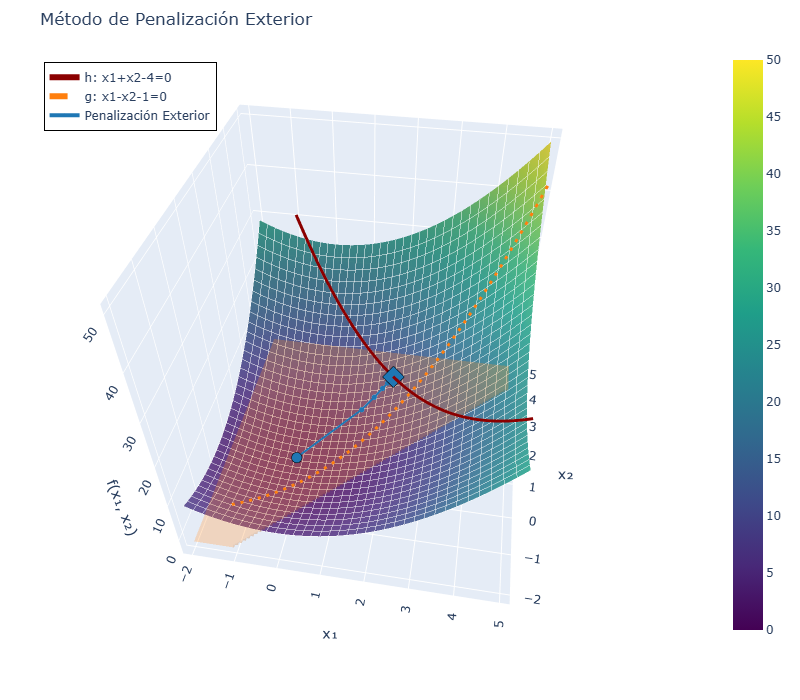

Esta visualización permite ver que la superficie objetivo es un paraboloide elíptico y que, consecuentemente, la región factible posee curvatura. Por esta razón, dicho espacio es no-euclidiano y las líneas que se veían rectas en la visualización 2D anterior son realmente curvas.